In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Heart_disease_cleveland_new.csv')
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,0,145,233,1,2,150,0,2.3,2,0,2,0
1,67,1,3,160,286,0,2,108,1,1.5,1,3,1,1
2,67,1,3,120,229,0,2,129,1,2.6,1,2,3,1
3,37,1,2,130,250,0,0,187,0,3.5,2,0,1,0
4,41,0,1,130,204,0,2,172,0,1.4,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45,1,0,110,264,0,0,132,0,1.2,1,0,3,1
299,68,1,3,144,193,1,0,141,0,3.4,1,2,3,1
300,57,1,3,130,131,0,0,115,1,1.2,1,1,3,1
301,57,0,1,130,236,0,2,174,0,0.0,1,1,1,1


In [3]:
df.duplicated().sum()
#no duplicates

np.int64(0)

In [4]:
df.info()
#Feature Description

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [5]:
df.isna().sum()
#Data is Clean No Null Values

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [6]:
df.describe().T
#Check statistics of the features

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,2.158416,0.960126,0.0,2.0,2.0,3.0,3.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


array([[<Axes: title={'center': 'age'}>, <Axes: title={'center': 'sex'}>,
        <Axes: title={'center': 'cp'}>],
       [<Axes: title={'center': 'trestbps'}>,
        <Axes: title={'center': 'chol'}>,
        <Axes: title={'center': 'fbs'}>],
       [<Axes: title={'center': 'restecg'}>,
        <Axes: title={'center': 'thalach'}>,
        <Axes: title={'center': 'exang'}>],
       [<Axes: title={'center': 'oldpeak'}>,
        <Axes: title={'center': 'slope'}>,
        <Axes: title={'center': 'ca'}>],
       [<Axes: title={'center': 'thal'}>,
        <Axes: title={'center': 'target'}>, <Axes: >]], dtype=object)

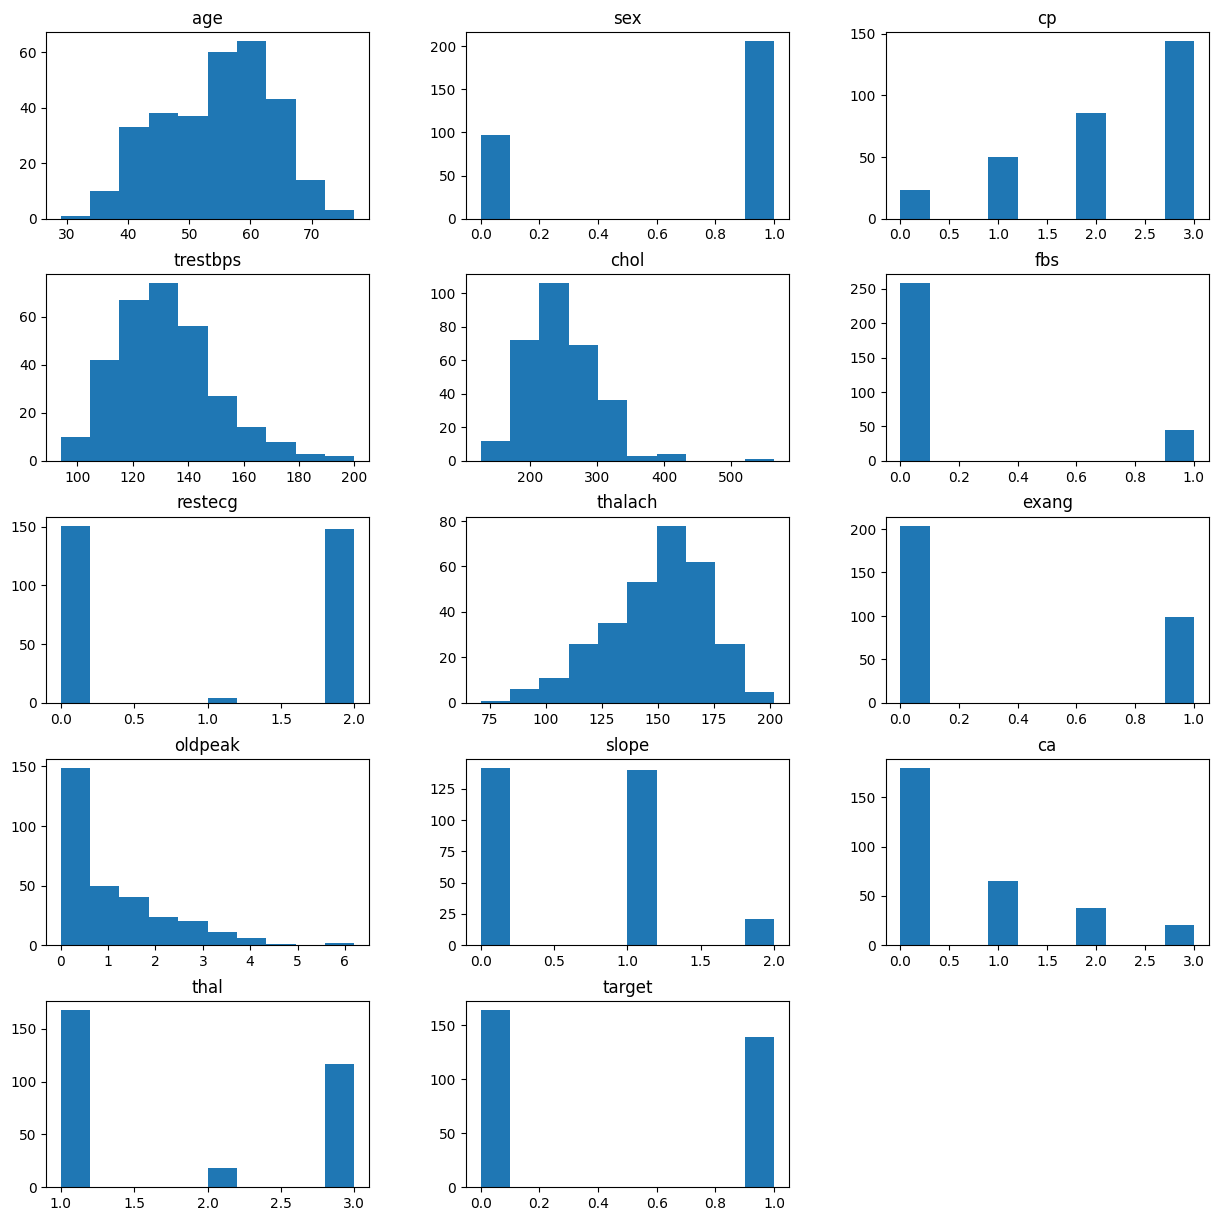

In [7]:
#histogram of Features
df.hist( 
    figsize=(15, 15),
    grid=False,
    layout=(5, 3)
)

In [8]:
#numerical Columns
num_cols = ['age','trestbps','chol','thalach','oldpeak']

#Categorical Columns
cat_cols = ['sex','cp','fbs','restecg','exang','slope','ca','thal',]

In [9]:
from sklearn.model_selection import train_test_split
#25% test and 75% train split
X_train,X_test,y_train,y_test = train_test_split(df[num_cols + cat_cols],df['target'],test_size=0.25,random_state=42)

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

#numercial features pipeline
num_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='mean')),
    ('scale', StandardScaler())
])

#categorical features pipeline
cat_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('encode', OneHotEncoder(handle_unknown='ignore'))
])

#column transformer on numerical and categorical features
preprocess_transformer = ColumnTransformer([
    ('num_step', num_pipeline, num_cols),
    ('cat_step', cat_pipeline, cat_cols)
])        

In [11]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score

def try_model_StratifiedKFold(X,y,model) :
    #pre-process and train pipeline
    p = Pipeline([
        ('pre-process',preprocess_transformer),
        ('model',model)
    ])

    skf = StratifiedKFold(shuffle=True,random_state=42,n_splits=10)

    scores = []

    for train_idx,val_idx in skf.split(X,y) :
        X_fold_train,X_val = X.iloc[train_idx],X.iloc[val_idx]
        y_fold_train,y_val = y.iloc[train_idx],y.iloc[val_idx]

        p.fit(X_fold_train,y_fold_train)
        
        y_train_pred = p.predict(X_fold_train)
        y_val_pred = p.predict(X_val)

        scores.append((accuracy_score(y_fold_train,y_train_pred),accuracy_score(y_val,y_val_pred)))

    return scores

In [12]:
from sklearn.model_selection import GridSearchCV

def get_best_parameters(X,y,p,params) :
    gs = GridSearchCV(
                        estimator=p,
                        param_grid=params,
                        cv=10,
                        scoring='accuracy',
                        n_jobs=-1,
                    )
    gs.fit(X,y)
    return gs.best_params_

In [13]:
def test_model(model) :
    pipe = Pipeline([
        ('pre-process',preprocess_transformer),
        ('model',model)
    ]).fit(X_train,y_train)

    return pipe.predict(X_test),pipe.predict_proba(X_test)

In [14]:
from sklearn.svm import SVC

svm_pipeline = Pipeline([
        ('pre-process',preprocess_transformer),
        ('model',SVC())
    ])

svm_params = {
    'model__C' : np.arange(0.1,1,0.1),
    'model__gamma' : ['auto',1,0.1,0.01,0.001],
    'model__kernel':['rbf','poly','linear']
}

print('SVM best parameters:')
get_best_parameters(X_train,y_train,svm_pipeline,svm_params)

SVM best parameters:


{'model__C': np.float64(0.6), 'model__gamma': 0.01, 'model__kernel': 'rbf'}

In [15]:
from sklearn.tree import DecisionTreeClassifier

dt_pipline = Pipeline([
    ('pre-process',preprocess_transformer),
    ('model',DecisionTreeClassifier(random_state=42))
])

dt_params = {
    'model__ccp_alpha': np.arange(0.01,0.05,0.01),
    'model__max_depth': [3, 4, 5, 7],
    'model__min_samples_leaf': np.arange(2,10,1),
    'model__min_samples_split': np.arange(2,10,1)
}

print('Decision Tree best parameters:')
get_best_parameters(X_train,y_train,dt_pipline,dt_params)

Decision Tree best parameters:


{'model__ccp_alpha': np.float64(0.01),
 'model__max_depth': 4,
 'model__min_samples_leaf': np.int64(8),
 'model__min_samples_split': np.int64(2)}

In [16]:
from sklearn.ensemble import AdaBoostClassifier

ada_pipeline = Pipeline([
    ('pre-process',preprocess_transformer),
    ('model',AdaBoostClassifier(random_state=42))
])

ada_params={
    'model__n_estimators' : [10,50,100,200],
    'model__learning_rate': [0.01, 0.1, 0.5, 1.0]
}

print('Ada Boost best parameters:')
get_best_parameters(X_train,y_train,ada_pipeline,ada_params)

Ada Boost best parameters:


{'model__learning_rate': 0.1, 'model__n_estimators': 50}

In [17]:
from sklearn.neural_network import MLPClassifier

import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

mlp_pipeline = Pipeline([
     ('pre-process',preprocess_transformer),
     ('model',MLPClassifier(random_state=42))
])

mlp_params = {
    'model__hidden_layer_sizes' : [(32,),(32,32),(64,64),(64,),(64,32),(64,32,16)],
    'model__max_iter' : [100,500,1000],
    'model__learning_rate' : ['constant', 'invscaling', 'adaptive'],
    'model__activation' : ['identity', 'logistic', 'tanh', 'relu']
}
print('MLP best parameters:')
get_best_parameters(X_train,y_train,mlp_pipeline,mlp_params)

MLP best parameters:


{'model__activation': 'logistic',
 'model__hidden_layer_sizes': (64, 32),
 'model__learning_rate': 'constant',
 'model__max_iter': 500}

In [18]:
svm_model = SVC(kernel='rbf',C=0.6,gamma=0.01,probability=True)
res_svm = try_model_StratifiedKFold(X_train,y_train,svm_model)

dt_model = DecisionTreeClassifier(random_state=42,ccp_alpha=0.01,max_depth=4,min_samples_leaf=8,min_samples_split=2)
res_dt = try_model_StratifiedKFold(X_train,y_train,dt_model)

ada_model = AdaBoostClassifier(random_state=42,n_estimators=50,learning_rate=0.1)
res_ada = try_model_StratifiedKFold(X_train,y_train,ada_model)

mlp_model = MLPClassifier(random_state=42,hidden_layer_sizes=(64,32),max_iter=500,learning_rate='constant',activation='logistic')
res_mlp = try_model_StratifiedKFold(X_train,y_train,mlp_model)

print('='*5,'Training and Validation Accuracy Scores','='*5)
print(f'SVM : {np.mean(res_svm,axis=0) * 100}')
print(f'Decision Tree: {np.mean(res_dt,axis=0) * 100}')
print(f'Ada Boosting: {np.mean(res_ada,axis=0) * 100}')
print(f'MLP :{np.mean(res_mlp,axis=0) * 100}')

===== Training and Validation Accuracy Scores =====
SVM : [85.9033955 85.       ]
Decision Tree: [86.0011956  76.12648221]
Ada Boosting: [85.95217599 83.26086957]
MLP :[85.12123386 84.09090909]


In [19]:
print(5*'=','Test Scores',5*'=')
y_svm,svm_proba = test_model(svm_model)
y_dt,dt_proba = test_model(dt_model)
y_ada,ada_proba = test_model(ada_model)
y_mlp,mlp_proba = test_model(mlp_model)
print(f'SVM: {accuracy_score(y_test,y_svm) * 100:.5f}')
print(f'Decision Tree: {accuracy_score(y_test,y_dt) * 100:.5f}')
print(f'Ada Boosting: {accuracy_score(y_test,y_ada) * 100:.5f}')
print(f'MLP : {accuracy_score(y_test,y_mlp) * 100:.5f}')

===== Test Scores =====
SVM: 82.89474
Decision Tree: 81.57895
Ada Boosting: 88.15789
MLP : 84.21053


In [20]:
from sklearn.metrics import roc_auc_score

print(5*'=',"Test Sets ROC AUC SCORE",5*'=')
print(f'SVM : {roc_auc_score(y_test,svm_proba[:,1])}')
print(f'Decision Tree: {roc_auc_score(y_test,dt_proba[:,1])}')
print(f'Ada Boosting: {roc_auc_score(y_test,ada_proba[:,1])}')
print(f'MLP: {roc_auc_score(y_test,mlp_proba[:,1])}')

===== Test Sets ROC AUC SCORE =====
SVM : 0.9199584199584199
Decision Tree: 0.8572418572418572
Ada Boosting: 0.9338184338184339
MLP: 0.9119889119889121


In [21]:
from sklearn.metrics import classification_report

print(20*'=',"SVM metrics",20*'=')
print(classification_report(y_test,y_svm))
print()

print(20*'=',"DT metrics",20*'=')
print(classification_report(y_test,y_dt))
print()

print(20*'=',"ADA metrics",20*'=')
print(classification_report(y_test,y_ada))
print()

print(20*'=',"MLP metrics",20*'=')
print(classification_report(y_test,y_mlp))
print()

==================== SVM metrics ====================
              precision    recall  f1-score   support

           0       0.81      0.87      0.84        39
           1       0.85      0.78      0.82        37

    accuracy                           0.83        76
   macro avg       0.83      0.83      0.83        76
weighted avg       0.83      0.83      0.83        76


==================== DT metrics ====================
              precision    recall  f1-score   support

           0       0.80      0.85      0.82        39
           1       0.83      0.78      0.81        37

    accuracy                           0.82        76
   macro avg       0.82      0.81      0.82        76
weighted avg       0.82      0.82      0.82        76


==================== ADA metrics ====================
              precision    recall  f1-score   support

           0       0.88      0.90      0.89        39
           1       0.89      0.86      0.88        37

    accuracy       

==================== SVM ROC Curve ====================


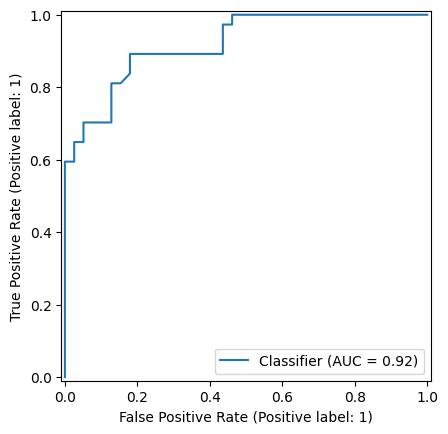

In [22]:
from sklearn.metrics import RocCurveDisplay
print(20*'=',"SVM ROC Curve",20*'=')
RocCurveDisplay.from_predictions(y_test,svm_proba[:,1])

==================== DT ROC Curve ====================


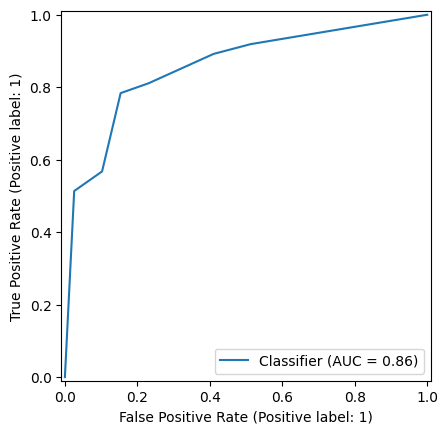

In [23]:
print(20*'=',"DT ROC Curve",20*'=')
RocCurveDisplay.from_predictions(y_test,dt_proba[:,1])

==================== ADA ROC Curve ====================


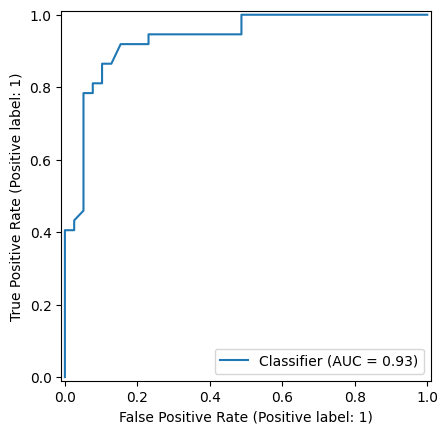

In [24]:
print(20*'=',"ADA ROC Curve",20*'=')
RocCurveDisplay.from_predictions(y_test,ada_proba[:,1])

==================== MLP ROC Curve ====================


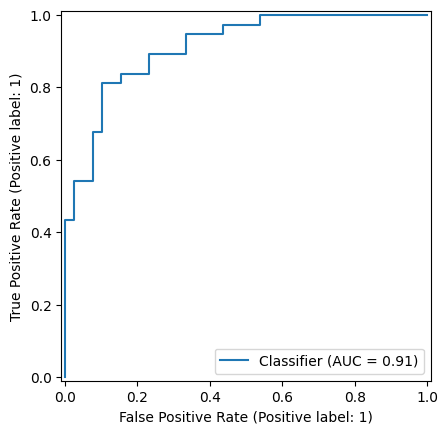

In [25]:
print(20*'=',"MLP ROC Curve",20*'=')
RocCurveDisplay.from_predictions(y_test,mlp_proba[:,1])